<a href="https://colab.research.google.com/github/diegoax/ALNAE-2026/blob/main/Notebooks/clase16_ALNAE_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clase 16 (Miércoles 3 de junio, 2026)

# En dimensión infinita: datos funcionales

In [ ]:
library(magrittr)

In [ ]:
fpca_base <- function(Y, argvals = NULL, ncomp = 2, centered = FALSE) {
  # Y: Matriz de N (curvas/individuos) x M (puntos de tiempo)
  N <- nrow(Y)
  M <- ncol(Y)

  if (is.null(argvals)) {
    argvals <- seq(0, 1, length.out = M)
  }

  # 1. Centrar los datos (restar la curva promedio)
  mean_curve <- colMeans(Y)
  Y_centered <- sweep(Y, 2, mean_curve, "-")

  if (!centered) Y_centered = Y

  # 2. Calcular pesos de cuadratura (Regla del Trapecio para la integral)
  diffs <- diff(argvals)
  w <- numeric(M)
  w[1] <- diffs[1] / 2
  w[M] <- diffs[length(diffs)] / 2
  if (M > 2) {
    w[2:(M-1)] <- (diffs[1:(M-2)] + diffs[2:(M-1)]) / 2
  }

  # 3. Transformar la matriz con la raíz de los pesos
  sqrt_w <- sqrt(w)
  Y_star <- sweep(Y_centered, 2, sqrt_w, "*")

  # 4. Aplicar SVD (Descomposición en Valores Singulares)
  svd_res <- svd(Y_star)

  # 5. Calcular Eigenvalores y Proporción de Varianza
  eigenvalues <- (svd_res$d^2) / (N - 1)
  var_prop <- eigenvalues / sum(eigenvalues)

  # 6. Extraer Componentes Principales (Harmonics) y Scores
  idx <- 1:ncomp
  # Ajustar los vectores propios por los pesos para que la norma funcional sea 1
  harmonics <- sweep(svd_res$v[, idx, drop = FALSE], 1, sqrt_w, "/")
  scores <- Y_star %*% svd_res$v[, idx, drop = FALSE]

  # Formatear nombres
  colnames(harmonics) <- paste0("PC", idx)
  colnames(scores) <- paste0("PC", idx)

  # Devolver lista con estructura similar a pca.fd
  return(list(
    mean_curve = mean_curve,
    harmonics = harmonics,   # Equivalente a pcafd$harmonics
    scores = scores,         # Equivalente a pcafd$scores
    values = eigenvalues[idx], # Eigenvalores
    var_prop = var_prop[idx], # Varianza explicada por componente
    argvals = argvals
  ))
}

## Ejemplo 1



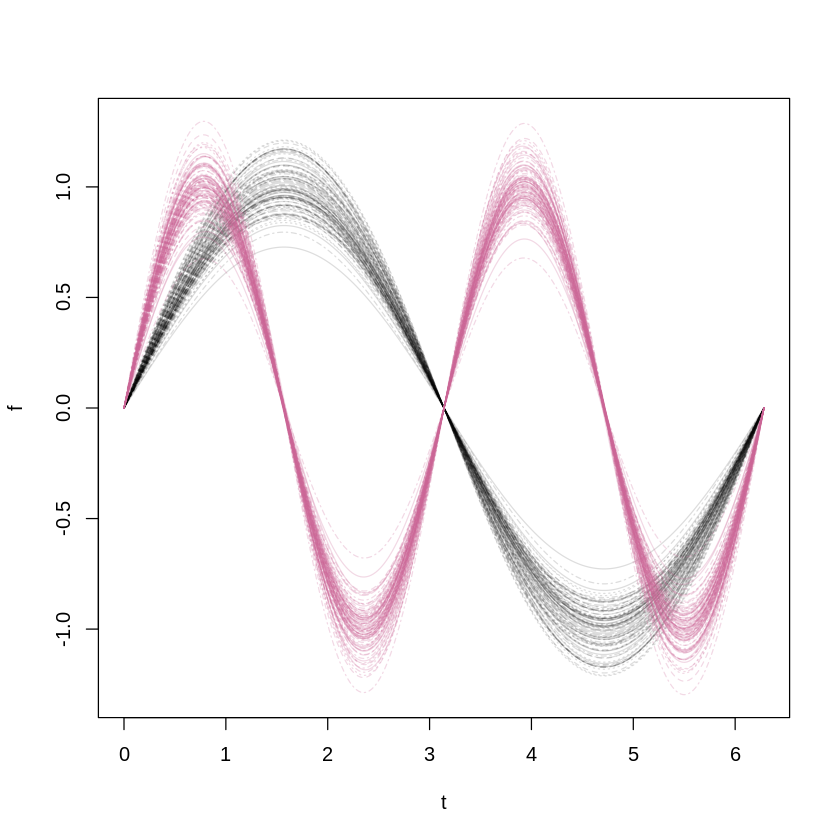

In [ ]:
t <- seq(0,2*pi, length = 301)

set.seed(1234)
f <- replicate(100, {
  rnorm(1,1,.1)*sin(t) + rnorm(1,0,.01)*sin(3*t)
})

f <- cbind(f, replicate(100, {
  rnorm(1,1,.1)*sin(2*t) + rnorm(1,0,.01)*sin(3*t)
}))

matplot(t,f, type = 'l', col = rep(c("#00000022",'#CC66993F'), each = 100))

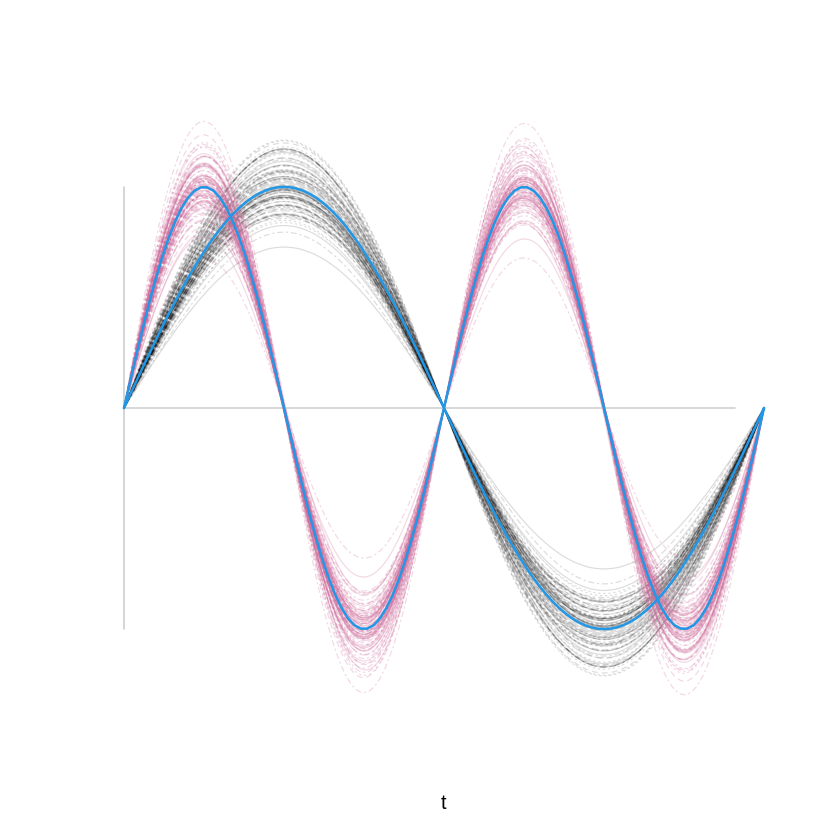

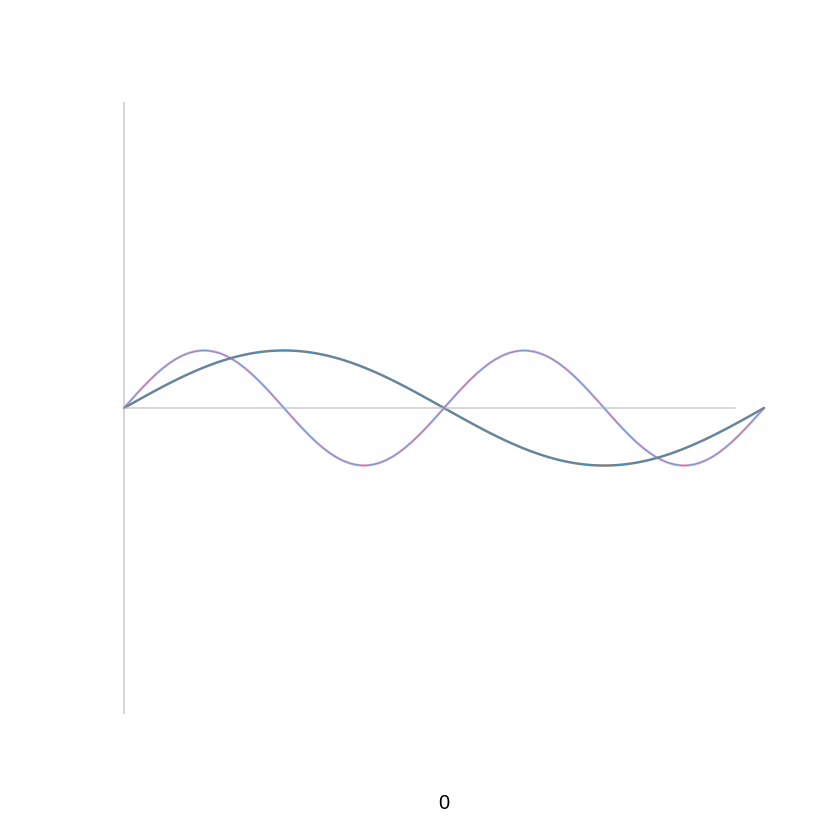

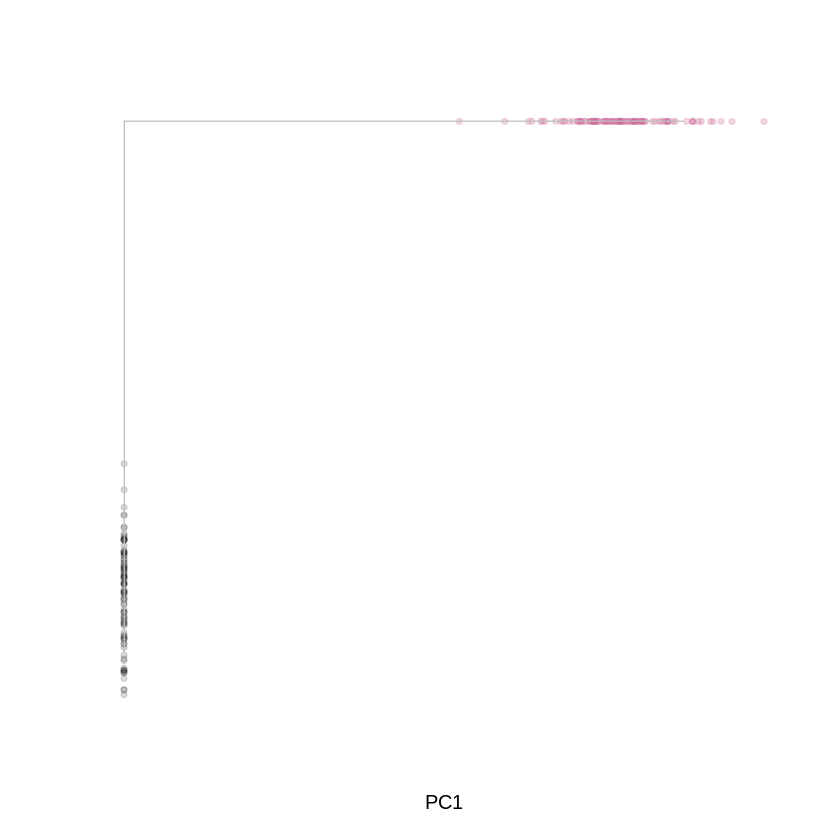

In [ ]:
sf_pca = fpca_base(t(f), t)

matplot(t,f, type = 'l', col = rep(c("#00000022",'#CC66993F'), each = 100), axes = F, ylab = '')
axis(1, pos = 0, labels = F, lwd.ticks = 0, col = 'grey')
axis(2, pos = 0, labels = F, lwd.ticks = 0, col = 'grey')
curve(sin(x), add = T, col = 4, lwd = 2)
curve(sin(2*x), add = T, col = 4, lwd = 2)

plot(0, 0, col = '#00000022', xlim = c(0,2*pi), ylim = c(-.6,.6),type = 'n', ylab = '', axes = F, asp = 1)
lines(t, -sf_pca$harmonics[,2], lwd = 2, col = 'grey50')
lines(t, sf_pca$harmonics[,1], lwd = 2, col = '#CC669999')
axis(1, pos = 0, labels = F, lwd.ticks = 0, col = 'grey')
axis(2, pos = 0, labels = F, lwd.ticks = 0, col = 'grey')
curve(sin(x)/sqrt(pi), add = T, col = 4, lwd = .5)
curve(sin(2*x)/sqrt(pi), add = T, col = 4, lwd = .5)

plot(sf_pca$scores, col = rep(c("#00000022","#CC66993F"), each = 100), pch = 20, axes = F, ylab = '')
axis(1, pos = 0, labels = F, lwd.ticks = 0, col = 'grey')
axis(2, pos = 0, labels = F, lwd.ticks = 0, col = 'grey')

## Ejemplo 2

Dados
 - $Y_i \in \{-1, 1\}$
 - $\{Z_{ij}\}{\substack{i = 1, \dots, n\\ j = 1, \dots, 5}}$ variables aleatorias independientes, con la misma distribución de probabilidad, que toman exclusivamente valores positivos, y que se concentran alrededor de 1.
 - Una constante $c_0 = 0.15$

Definimos $$X_i(t) = \sum_{j=1}^5 Y_i Z_{ij} c_0^{j-1} \sin(j t),$$ para $t \in [0, 2\pi]$.

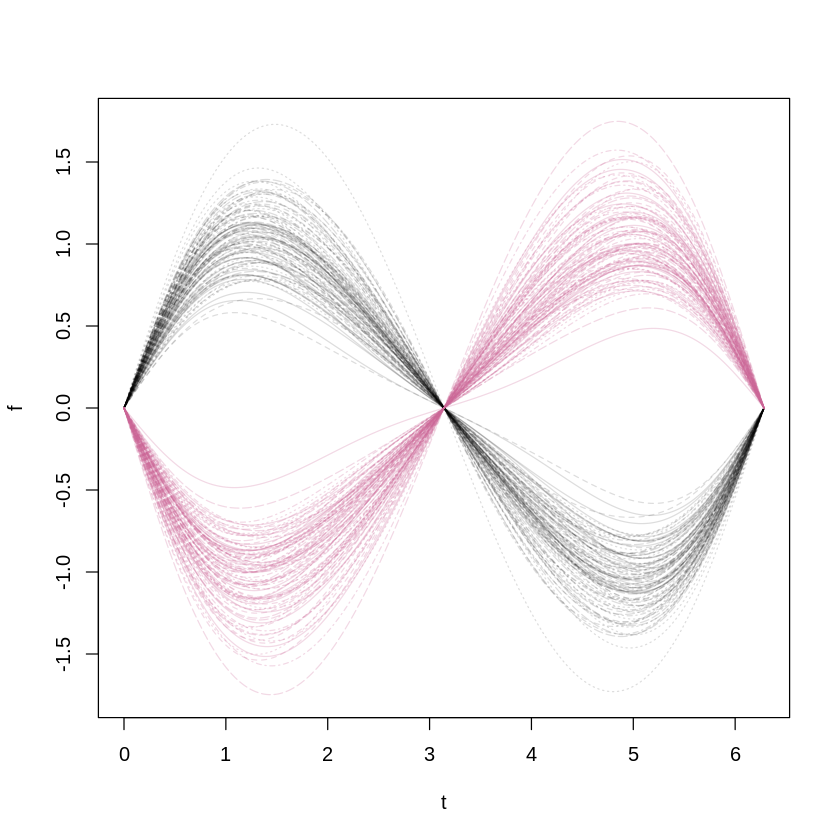

In [ ]:
t <- seq(0,2*pi, length = 301)

l <- 5
coefs <- .15^(1:l-1)

set.seed(1234)
f <- replicate(100, {
  rowSums(sapply(1:l, function(j) abs(rnorm(1,1,.1))^2*coefs[j]*sin(t*j)))
})

f <- cbind(f, replicate(100, {
  rowSums(sapply(1:l, function(j) -abs(rnorm(1,1,.12))^2*coefs[j]*sin(t*j)))
}))


matplot(t,f, type = 'l', col = rep(c("#00000022",'#CC66993F'), each = 100))


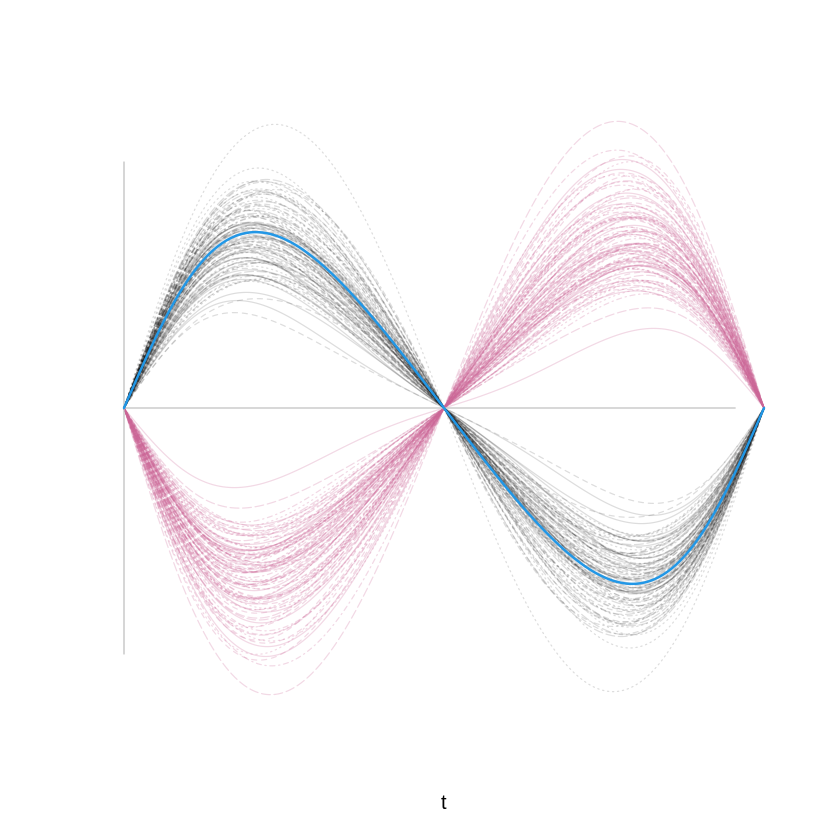

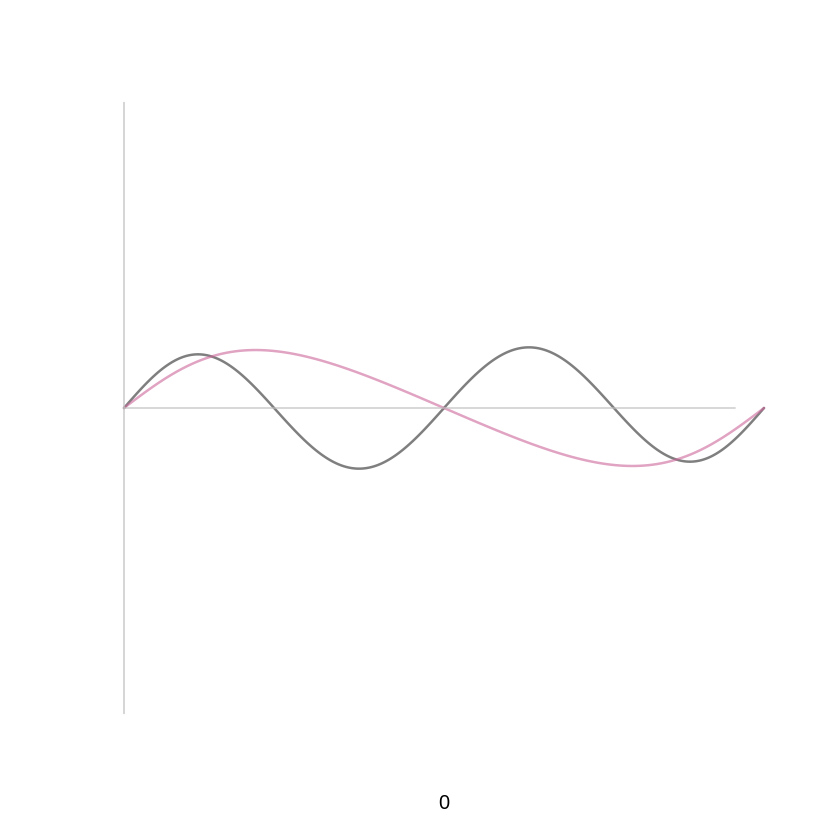

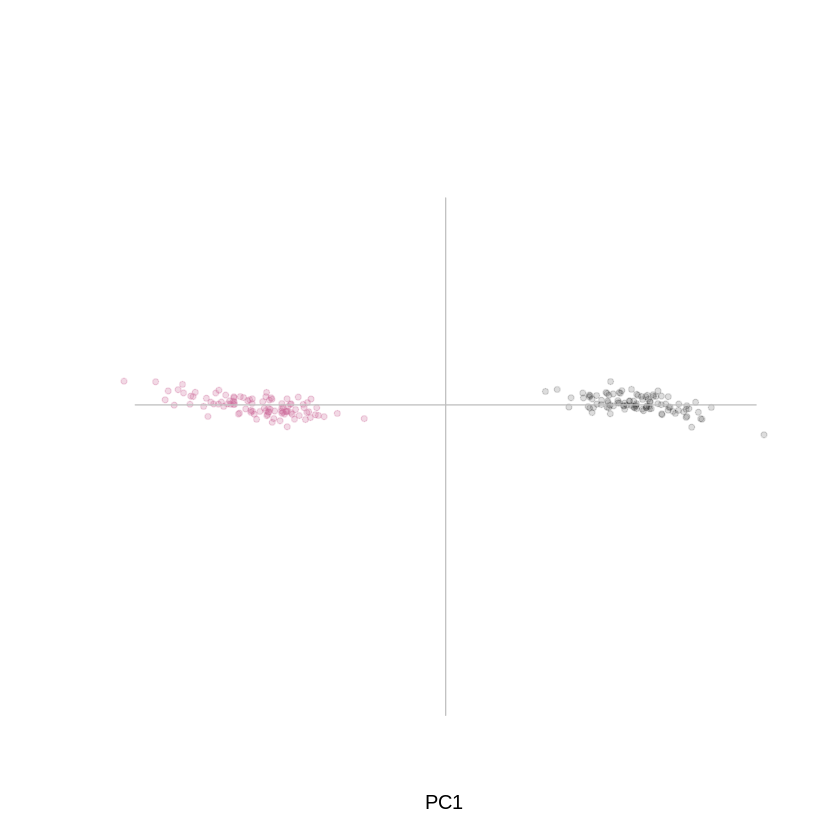

In [ ]:
sf_pca = fpca_base(t(f), t)

matplot(t,f, type = 'l', col = rep(c("#00000022",'#CC66993F'), each = 100), axes = F, ylab = '')
axis(1, pos = 0, labels = F, lwd.ticks = 0, col = 'grey')
axis(2, pos = 0, labels = F, lwd.ticks = 0, col = 'grey')
lines(t, sf_pca$harmonics[,1]*sqrt(sf_pca$values[1]), lwd = 2, col = 4)

plot(0, 0, col = '#00000022', xlim = c(0,2*pi), ylim = c(-.6,.6),type = 'n', ylab = '', axes = F, asp = 1)
lines(t, sf_pca$harmonics[,2], lwd = 2, col = 'grey50')
lines(t, sf_pca$harmonics[,1], lwd = 2, col = '#CC669999')
axis(1, pos = 0, labels = F, lwd.ticks = 0, col = 'grey')
axis(2, pos = 0, labels = F, lwd.ticks = 0, col = 'grey')

plot(sf_pca$scores, col = rep(c("#00000022","#CC66993F"), each = 100), pch = 20, axes = F, ylab = '', asp = 1)
axis(1, pos = 0, labels = F, lwd.ticks = 0, col = 'grey')
axis(2, pos = 0, labels = F, lwd.ticks = 0, col = 'grey')

Para un ejemplo con datos reales ver https://github.com/diegoax/ALNAE-2026/blob/main/fda_phoneme.pdf